# Include functions from function file

# Include functions from function file

## Include

In [1]:

cd("C:/Users/mjbarillas/Documents/GitHub/Mimosa/")


In [2]:
using JLD2

In [3]:
include("C:/Users/mjbarillas/Documents/GitHub/Mimosa/scripts/MB Ex/kPCA/TB/ex2_aa_kPCA_TB_ST4SL4.jl")

Voltage_Optimization2 (generic function with 1 method)

In [4]:
include("C:/Users/mjbarillas/Documents/GitHub/Mimosa/scripts/Scratch/BPSO.jl")

Objective (generic function with 1 method)

In [5]:
include("C:/Users/mjbarillas/Documents/GitHub/Mimosa/scripts/MB Ex/TB ST4 SL4/ex0_stat_EM_TubeBeam_St&Sl.jl")

run_candidates (generic function with 1 method)

## Plots Backends

In [6]:
plotlyjs(size=(800,800))


Plots.PlotlyJSBackend()

In [7]:
gr(size=(800,800))

Plots.GRBackend()

# ROM offline

## Data collection

200 rand is the base state at which everything is tested

In [8]:
St, Sl, pot_list, N_rand = 4, 4, [2000,3000,4000,5000], 200
conf_list, X = ReadData(St,Sl,pot_list,N_rand)

([0 1 … 0 1; 0 0 … 0 0; … ; 0 0 … 0 1; 0 0 … 1 0], [0.0 0.0 … 0.0 0.0; 0.003571428571430387 0.0035760141855762546 … 0.0035995839865282614 0.003631334138149885; … ; -3.049318610115481e-20 -0.0039130996209062715 … 0.03137838629882813 0.013757098424891907; -3.105787473265768e-20 -0.004079949356178715 … 0.03355656085819472 0.013758706435503686])

In [9]:
_,N = size(X)

(87, 1056)

## Get data from JLD2 file

In [ ]:
Data = load("data/Sensitibity_to_TSsize_$N_rand+64.jdl2")

In [ ]:
D = Data["D"]
U = D[:U]
t_1 = D[:t_1]
Ḡ = D[:Ḡ]
G = D[:G]
Λ = D[:Λ]
Y_ = D[:Y_]
D_G_sym = D[:D_G_sym]
U_ = D[:U_]
Z_ = D[:Z_]

## Plot test

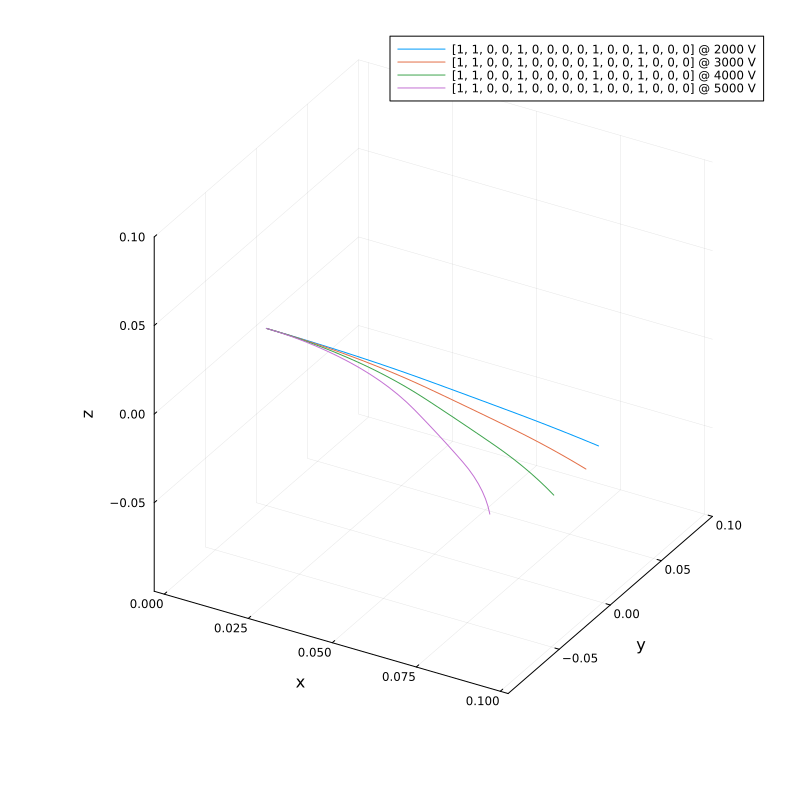

In [10]:
conf_i = 970-264*3
p = plot_x(X[:,conf_i],"$(conf_list[:,conf_i]) @ 2000 V")
for i in 1:3
    p = plot_x!(X[:,conf_i+264*i],"$(conf_list[:,conf_i]) @ $((i+2)*1000) V")
end
zlims!(-0.1,0.1); ylims!(-0.1,0.1)

## kPCA

Optimized $\beta$ for TS with voltages 2000:1000:5000

In [11]:
β = 2.5917492241092597

2.5917492241092597

In [ ]:
# Test of the optimization (do not use for paper)
# β = 7.61625646882277


In [12]:
k=3
Κ(X1,X2) = exp(-β*(dot(X1-X2,X1-X2)))


Κ (generic function with 1 method)

In [13]:
Λ, U, U_, Ḡ, G = kPOD(Κ, X, k)
Z_ = real.(U_'*Ḡ)

3×1056 Matrix{Float64}:
 0.00712608  0.0174332   0.0441908   0.0412031  …  -0.255478   -0.101587
 0.00034768  0.0373126  -0.00997746  0.0195159      0.0722624  -0.0117681
 0.0163449   0.0141049   0.015296    0.014669      -0.0686469   0.00363381

In [ ]:
plot_eigen(Λ)

In [ ]:
Λ = real.(Λ)
Λ_rel = (Λ./sum(Λ))*100
Λ_s = [sum(Λ_rel[[1:i...]]) for i in 1:10]

In [ ]:
scatter(
    eachrow(Z_)...,xlabel="z1",ylabel="z2",zlabel="z3",
    color=[group_pot(i,N,4) for i in 1:N],
    label=false, xlims=(minimum(Z_),maximum(Z_)),
    ylims=(minimum(Z_),maximum(Z_)),
    zlims=(minimum(Z_),maximum(Z_)),
    hover=[i for i in 1:N],
    markersize=3
)

## isomap

In [ ]:
println(Threads.nthreads())

In [14]:
neighbors = 25
Y_, D_G_sym = isomap1(neighbors,Z_)


100.0 %                         


([0.0074767403526177665 0.021711510597509663 … -0.2613690597945351 -0.10418247985472824; 0.0010098170356529926 -0.034689667726298015 … -0.1077018781207492 -0.0002878807430136867], [0.0 0.03854014334417988 … 0.2891786406258281 0.1118474825034185; 0.03854014334417988 0.0 … 0.2939101051280588 0.1306617325336031; … ; 0.2891786406258281 0.2939101051280588 … 0.0 0.19217651151702067; 0.1118474825034185 0.1306617325336031 … 0.19217651151702067 0.0])

In [ ]:
using DataFrames
df = DataFrame(Y_, :auto)
mkdir("data/csv/EM_TB_St4_Sl4_Y_beta_$(round(β,digits = 4))_nh_$(neighbors)_Nrand_$N_rand")
CSV.write("data/csv/EM_TB_St4_Sl4_Y_beta_$(round(β,digits = 4))_nh_$(neighbors)_Nrand_$N_rand/temp.csv", df)

In [ ]:
s = scatter(eachrow(Y_)...,xlabel="y1",ylabel="y2",label="TS",legend=:outerbottom,
    # legend_columns=2,
    color=[group_pot(i,N,4) for i in 1:N])

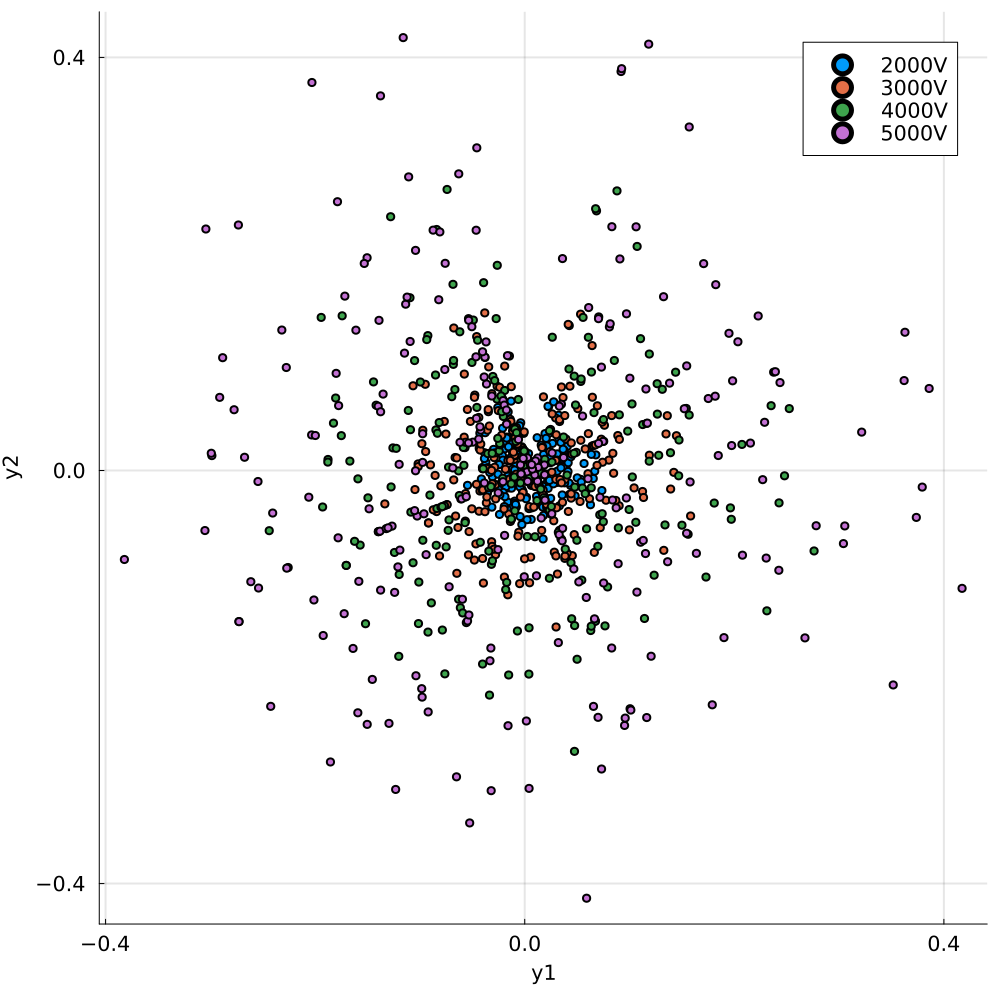

In [15]:
s = scatter([Y_[1,[264*(i-1)+1:264*i...]] for i in 1:4],[Y_[2,[264*(i-1)+1:264*i...]] for i in 1:4],xlabel="y1",ylabel="y2",
    size=(1000,1000),
    # hover=collect(1:256),
    grid = true, gridlinewidth = 2,
    xticks=[round(minimum(Y_[1,:]),digits=1),0.0,round(maximum(Y_[1,:]),digits=1)...],
    yticks=[round(minimum(Y_[2,:]),digits=1),0.0,round(maximum(Y_[2,:]),digits=1)...],
    markersize = 4,
    label=["2000V" "3000V" "4000V" "5000V"],
    # color=[group_pot(i,N,4) for i in 1:N],
    tickfontsize=14,
    guidefontsize=14,
    legendfontsize=14,
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi_isomap.svg")

In [16]:
pot_list_ = []
for pot in pot_list
    push!(pot_list_,[pot for i in 1:Int(N/length(pot_list))])
end
pot_list_ = reduce(vcat,pot_list_);

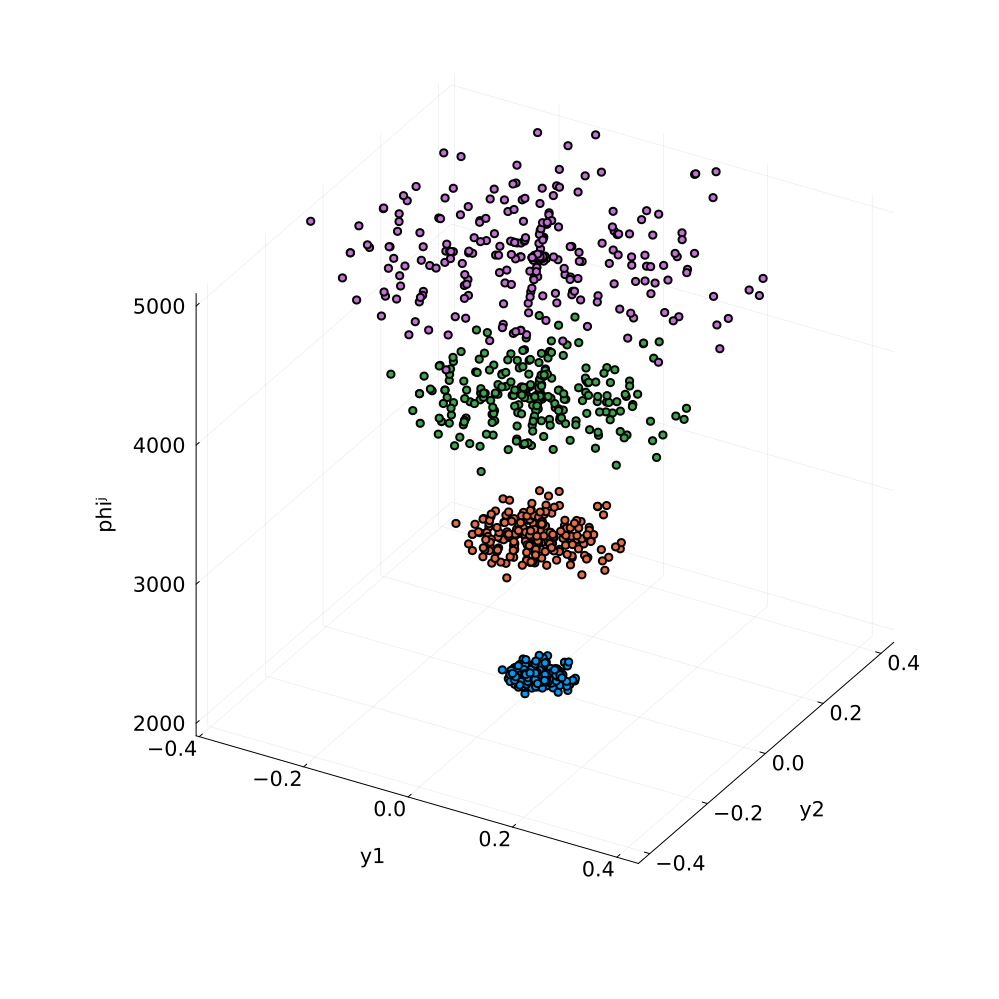

In [23]:
s = scatter(eachrow(Y_)...,pot_list_,xlabel="y1",ylabel="y2",zlabel="phiʲ",
    legend=:false,
    color=[group_pot(i,N,4) for i in 1:N],
    size=(1000,1000),
    markersize=4,
    tickfontsize=14,
    guidefontsize=14,
    )

In [29]:
list = [201,202,203,205]
list_ = [[i,i+264,i+264*2,i+264*3] for i in list]
list__ = reduce(vcat,list_)

16-element Vector{Int64}:
 201
 465
 729
 993
 202
 466
 730
 994
 203
 467
 731
 995
 205
 469
 733
 997

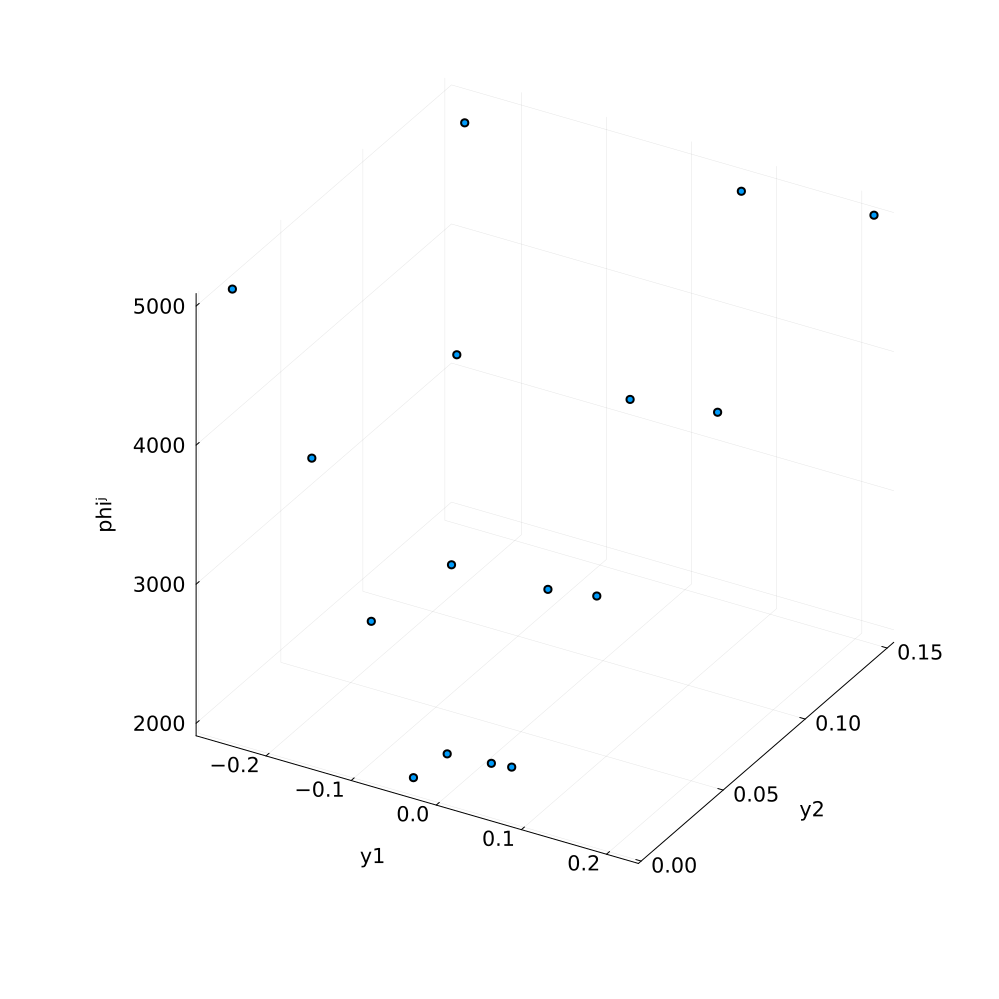

In [31]:
s = scatter(eachrow(Y_[:,list__])...,pot_list_[list__],xlabel="y1",ylabel="y2",zlabel="phiʲ",
    legend=:false,
    # color=[group_pot(i,N,4) for i in 1:N],
    size=(1000,1000),
    markersize=4,
    tickfontsize=14,
    guidefontsize=14,
    )

In [32]:
Plots.savefig("C:/Users/mjbarillas/Documents/LaTeX/Conference presentation/VoltageInterpolation.svg")

"C:\\Users\\mjbarillas\\Documents\\LaTeX\\Conference presentation\\VoltageInterpolation.svg"

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi_isomap_by_phi.svg")

# Test data collection

In [ ]:
conf_list_test = CSV.File("data/csv/EM_TB_St4_Sl4_Phi2000_Random/EM_TB_ST4_SL4_ConfRand.csv") |> Tables.matrix
conf_list_test = conf_list_test[:,[1000-31:1000-2...]];


In [ ]:
size(conf_list_test)

In [ ]:
VS_Conf_list = [1:64...];

## Voltage interpolation 

# Interpolating the whole training set to the desired voltage

In [ ]:
pot = 4500
nh=1
n_test = 2
conf = conf_list_test[:,n_test]
_x = ReadData_i(4,4,conf,pot)
p = plot_x(_x,"FOS @ $pot")
x_gen_pot_list = []
for pot in pot_list
    nh = 1
    n_test = 2
    conf = conf_list_test[:,n_test]
    y_gen1 = VectorSearch(Y_,conf,pot,pot_list,VS_Conf_list)
    x_gen1 = ReverseMap4(y_gen1,conf,pot,Y_,X,conf_list,pot_list,nh)
    push!(x_gen_pot_list,x_gen1)
    _x = ReadData_i(4,4,conf,pot)
    plot_x!(_x,"FOS @ $pot")
    plot_x!(x_gen1,"AFOS @ $pot")
end
x_gen_pot_list = reduce(hcat,x_gen_pot_list)
# x_gen_interpol = _Interpolation(pot_list,x_gen_pot_list,pot)
x_gen_interpol = ReverseMap5(conf,pot,Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_interpol, "AFOS @ $pot cuibicly interpolated")
x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_interpol, "AFOS @ $pot cuibicly interpolating the TS then ReverseMap")
display(p)

## Test

In [ ]:
x_gen_list = []
Err = []
fail_ = []
time_ = []
for i in 1:30
    n_test = i
    println("test configuration in evaluation $n_test")
    nh = 1
    pot = 4500
    conf = conf_list_test[:,n_test]
    t0 = time()
    x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
    push!(time_,time()-t0)
    try
        _x = ReadData_i(4,4,conf,pot)
    err = norm(x_gen_interpol-_x)/norm(_x)
    push!(Err,err)
    catch
        push!(fail_,i)
    end
end

In [ ]:
time_avg = sum(time_)/length(time_)

In [ ]:
fail_

In [ ]:
for i in fail_
    println("Computing the failed configuration $i")
    ph, chache = main(; get_parameters(5000.0, conf_list_test[:,i], St, Sl,CenterLine_)...)
end


In [ ]:
bar(Err,xticks=[1:length(Err)...])

In [ ]:
sum(Err)/length(Err)

In [ ]:
maximum(Err)

In [ ]:
round(maximum(Err),digits=3)

In [ ]:
bar(Err,label="Error")
Err_avg = sum(Err)/30
plot!(collect(1:30),[Err_avg for _ in 1:30],
linestyle=:dash, linewidth=4, label="Mean Error = $(round(Err_avg,digits=4))",
grid = false, gridlinewidth = 2,
    tickfontsize = 14,
    guidefontsize=14,
    legendfontsize=14,
    ylims = (0.0,round(maximum(Err),digits=3)),
    yticks=[0.0,round(round(maximum(Err),digits=4)/2,digits=3),round(maximum(Err),digits=3)],
    xticks=[1,10,20,30],
    xlabel="Test configuration"
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Surrogate_Error.svg")

In [ ]:
println(argmin(Err))
pot = 4500
x_i_ = ReadData_i(4,4,conf_list_test[:,argmin(Err)],pot)
n = length(x_i_)
c_test_string = "["
for i in conf_list_test[:,argmin(Err)]
    c_test_string = c_test_string * "$i"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_)),digits=3),0.0,round(maximum(abs.(y_)),digits=3)],
zticks = [-round(maximum(abs.(z_)),digits=3),0.0,round(maximum(abs.(z_)),digits=3)],
ylims = (-1.1*round(maximum(abs.(y_)),digits=3),1.1*round(maximum(abs.(y_)),digits=3)),
zlims = (-1.15*round(maximum(abs.(z_)),digits=3),1.15*round(maximum(abs.(z_)),digits=3)),
)
nh = 1
x_i_ = ReverseMap6(conf_list_test[:,argmin(Err)],pot,Y_,X,conf_list,pot_list,nh)
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot!(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V ROM",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_))+0.001,digits=3),0.0,round(maximum(abs.(y_))+0.001,digits=3)],
zticks = [-round(maximum(abs.(z_))+0.001,digits=3),0.0,round(maximum(abs.(z_))+0.001,digits=3)],
ylims = (-1.1*round(maximum(abs.(y_))+0.001,digits=3),1.1*round(maximum(abs.(y_))+0.001,digits=3)),
zlims = (-1.15*round(maximum(abs.(z_))+0.001,digits=3),1.15*round(maximum(abs.(z_))+0.001,digits=3)),
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Surrogate_Error_min_$(argmin(Err)).svg")

In [ ]:
println(argmax(Err))
pot = 4500
x_i_ = ReadData_i(4,4,conf_list_test[:,argmax(Err)],pot)
n = length(x_i_)
c_test_string = "["
for i in conf_list_test[:,argmax(Err)]
    c_test_string = c_test_string * "$i"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_)),digits=3),0.0,round(maximum(abs.(y_)),digits=3)],
zticks = [-round(maximum(abs.(z_)),digits=3),0.0,round(maximum(abs.(z_)),digits=3)],
ylims = (-1.1*round(maximum(abs.(y_)),digits=3),1.1*round(maximum(abs.(y_)),digits=3)),
zlims = (-1.15*round(maximum(abs.(z_)),digits=3),1.15*round(maximum(abs.(z_)),digits=3)),
)
nh = 1
x_i_ = ReverseMap6(conf_list_test[:,argmax(Err)],pot,Y_,X,conf_list,pot_list,nh)
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot!(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V ROM",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_))+0.001,digits=3),0.0,round(maximum(abs.(y_))+0.001,digits=3)],
zticks = [-round(maximum(abs.(z_))+0.001,digits=3),0.0,round(maximum(abs.(z_))+0.001,digits=3)],
ylims = (-1.1*round(maximum(abs.(y_))+0.001,digits=3),1.1*round(maximum(abs.(y_))+0.001,digits=3)),
zlims = (-1.15*round(maximum(abs.(z_))+0.001,digits=3),1.15*round(maximum(abs.(z_))+0.001,digits=3)),
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Surrogate_Error_max_$(argmax(Err)).svg")

# Optimization to find Configuration and voltage of desired shape

## Data for optimization and comparisons

In [ ]:
nh = 1
n_test = 3
conf = conf_list_test[:,n_test]
pot = 4500
x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
_x = ReadData_i(4,4,conf,pot)
p = plot_x(_x,"FOS @ $conf & $pot")
p = plot_x!(x_gen_interpol, "AFOS @ $conf & $pot RM6")
Err = norm(x_gen_interpol-_x)/norm(_x)


In [ ]:
(1-Κ(x_gen_interpol,_x))^2

In [ ]:
display(p)

## Optimization over $\Kappa$ of desired shape and reverse map using BPSO

In [ ]:
function Obj_2(α)
    function Obj_int(Φ)
        x_gen_interpol = ReverseMap6(α,Φ,Y_,X,conf_list,pot_list,nh)
        Err = (1-Κ(x_gen_interpol,_x))^2
        return Err
    end
    Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50)
    return Opt_.minimum
end

reference

In [ ]:
(particles,
           Initial_X,
           Obj,w,c1,c2,iterations) =
           (100, [0 for _ in 1:16],Obj_2,0.2,2.0,0.2,100)


In [ ]:

state = optimize_BPSO(particles,
           Initial_X,
           Obj,w,c1,c2,iterations);

In [ ]:

state = optimize_BPSO(particles,
           Initial_X,
           Obj,w,c1,c2,iterations);

Change

In [ ]:
(particles,Initial_X,Obj,w,c1,c2,iterations) = (18*4, [0 for _ in 1:16],Obj_2,0.5,1.5,0.5,100)


In [ ]:
state = optimize_BPSO(particles, Initial_X, Obj, w, c1, c2, iterations);

In [ ]:
function Obj_int(Φ)
    x_gen_interpol = ReverseMap6(state.P_gbest,Φ,Y_,X,conf_list,pot_list,nh)
    Err = (1-Κ(x_gen_interpol,_x))^2
    return Err
end
Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50,show_trace=false)
Opt_.minimizer

In [ ]:
conf == state.P_gbest

In [ ]:
x_gen_ = ReverseMap6(state.P_gbest,Opt_.minimizer,Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_,"AFOS @ $(state.P_gbest) & $(Opt_.minimizer)")

In [ ]:
((maximum(state.V_c)))

In [ ]:
round.(sig.(maximum(state.V_c)),digits=2)

In [ ]:
sum(round.(sig.(maximum(state.V_c)),digits=2))/state.n

Repetition test

In [ ]:
result = []
for _ in 1:10
    state = optimize_BPSO(particles, Initial_X, Obj, w, c1, c2, iterations);
    push!(result,(conf == state.P_gbest, state.P_gbest))
end

In [ ]:
result

### Optimization test

### with 10 validations runs

In [ ]:
result_list = []
time_ = []
first_result_list = []
for n_test in 1:10
    println("n_test = $n_test Optimization = 1")
    result_list_test = [] 
    nh = 1
    # n_test = 2
    conf = conf_list_test[:,n_test]
    pot = 4500
    _x = ReadData_i(4,4,conf,pot)
    function Obj_2(α)
        function Obj_int(Φ)
            x_gen_interpol = ReverseMap6(α,Φ,Y_,X,conf_list,pot_list,nh)
            Err = (1-Κ(x_gen_interpol,_x))^2
            return Err
        end
        Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50)
        return Opt_.minimum
    end
    t0 = time()
    state = optimize_BPSO(particles, Initial_X, Obj, w, c1, c2, iterations);
    push!(time_,time()-t0)
    function Obj_int(Φ)
        x_gen_interpol = ReverseMap6(state.P_gbest,Φ,Y_,X,conf_list,pot_list,nh)
        Err = (1-Κ(x_gen_interpol,_x))^2
        return Err
    end
    Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50,show_trace=false)
    Voltage = round(Opt_.minimizer,digits = 0)
    _x_test = nothing
    try
        _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
        println("n_test = $n_test simulation = false")
    catch
        println("n_test = $n_test simulation = true")
        ph, chache = main(; get_parameters(Voltage, state.P_gbest, St, Sl,CenterLine_)...)
        _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
    end
    push!(result_list_test,[1,state.P_gbest,Voltage,norm(_x_test-_x)/norm(_x),_x_test])
    println("First error value = $(result_list_test[1][4])")
    push!(first_result_list,result_list_test[1][4])
    for i in 2:10
        println("n_test = $n_test Optimization = $i")
        state = optimize_BPSO(particles, Initial_X, Obj, w, c1, c2, iterations)
        for i in 1:lastindex(result_list_test)
            if state.P_gbest==result_list_test[i][2]
                result_list_test[i][1] += 1
            else
                Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50,show_trace=false)
                Voltage = round(Opt_.minimizer,digits = 0)
                try
                    _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
                    println("n_test = $n_test simulation = false")
                catch
                    println("n_test = $n_test simulation = true")
                    ph, chache = main(; get_parameters(Voltage, state.P_gbest, St, Sl,CenterLine_)...)
                    _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
                end
                push!(result_list_test,[1,state.P_gbest,Voltage,norm(_x_test-_x)/norm(_x),_x_test])
            end
        end
    end
    push!(result_list,result_list_test)

end

### Without validations runs

In [ ]:
result_list = []
time_ = []
first_result_list = []
for n_test in 1:30
    println("n_test = $n_test Optimization = 1")
    result_list_test = [] 
    nh = 1
    # n_test = 2
    conf = conf_list_test[:,n_test]
    pot = 4500
    _x = ReadData_i(4,4,conf,pot)
    function Obj_2(α)
        function Obj_int(Φ)
            x_gen_interpol = ReverseMap6(α,Φ,Y_,X,conf_list,pot_list,nh)
            Err = (1-Κ(x_gen_interpol,_x))^2
            return Err
        end
        Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50)
        return Opt_.minimum
    end
    (particles,Initial_X,Obj,w,c1,c2,iterations) = (18*4, [0 for _ in 1:16],Obj_2,0.5,1.5,0.5,100)
    t0 = time()
    state = optimize_BPSO(particles, Initial_X, Obj, w, c1, c2, iterations);
    push!(time_,time()-t0)
    function Obj_int(Φ)
        x_gen_interpol = ReverseMap6(state.P_gbest,Φ,Y_,X,conf_list,pot_list,nh)
        Err = (1-Κ(x_gen_interpol,_x))^2
        return Err
    end
    Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50,show_trace=false)
    Voltage = round(Opt_.minimizer,digits = 0)
    _x_test = nothing
    try
        _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
        println("n_test = $n_test simulation = false")
    catch
        println("n_test = $n_test simulation = true")
        ph, chache = main(; get_parameters(Voltage, state.P_gbest, St, Sl,CenterLine_)...)
        _x_test = ReadData_i_test_last(4,4,state.P_gbest,Voltage)
    end
    push!(result_list_test,[1,state.P_gbest,Voltage,norm(_x_test-_x)/norm(_x),_x_test])
    println("First error value = $(result_list_test[1][4])")
    push!(first_result_list,result_list_test[1][4])
    push!(result_list,result_list_test)

end

In [ ]:
result_list

In [ ]:
conf_list_test'


In [ ]:
result_err = [res[1][4] for res in result_list]
bar(result_err,xticks=[i for i in 1:10],label=false)

In [ ]:
bar(result_err,label="Error")
Err_avg = sum(result_err)/30
plot!(collect(1:30),[Err_avg for _ in 1:30],
linestyle=:dash, linewidth=4, label="Mean Error = $(round(Err_avg,digits=4))",
grid = false, gridlinewidth = 2,
    tickfontsize = 14,
    guidefontsize=14,
    legendfontsize=14,
    ylims = (0.0,round(maximum(result_err),digits=3)),
    yticks=[0.0,round(round(maximum(result_err),digits=4)/2,digits=3),round(maximum(result_err),digits=3)],
    xticks=[1,10,20,30],
    xlabel="Test configuration"
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Inverse_Error.svg")

In [ ]:
argmin(result_err)

In [ ]:
println(argmin(result_err))
pot = 4500
x_i_ = ReadData_i(4,4,conf_list_test[:,argmin(result_err)],pot)
n = length(x_i_)
c_test_string = "["
for i in conf_list_test[:,argmin(result_err)]
    c_test_string = c_test_string * "$i"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_)),digits=3),0.0,round(maximum(abs.(y_)),digits=3)],
zticks = [-round(maximum(abs.(z_)),digits=3),0.0,round(maximum(abs.(z_)),digits=3)],
ylims = (-1.1*round(maximum(abs.(y_)),digits=3),1.1*round(maximum(abs.(y_)),digits=3)),
zlims = (-1.15*round(maximum(abs.(z_)),digits=3),1.15*round(maximum(abs.(z_)),digits=3)),
)
nh = 1
x_i_ = result_list[argmin(result_err)][1][5]
c_test_string = "["
for i in result_list[argmin(result_err)][1][2]
    if i
        k = 1
    else
        k=0
    end
    c_test_string = c_test_string * "$k"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot!(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $(result_list[argmin(result_err)][1][3]) V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_))+0.001,digits=3),0.0,round(maximum(abs.(y_))+0.001,digits=3)],
zticks = [-round(maximum(abs.(z_))+0.001,digits=3),0.0,round(maximum(abs.(z_))+0.001,digits=3)],
ylims = (-1.1*round(maximum(abs.(y_))+0.001,digits=3),1.1*round(maximum(abs.(y_))+0.001,digits=3)),
zlims = (-1.15*round(maximum(abs.(z_))+0.001,digits=3),1.15*round(maximum(abs.(z_))+0.001,digits=3)),
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Surrogate_Inverse_min_$(argmin(result_err)).svg")

In [ ]:
println(argmax(result_err))
pot = 4500
x_i_ = ReadData_i(4,4,conf_list_test[:,argmax(result_err)],pot)
n = length(x_i_)
c_test_string = "["
for i in conf_list_test[:,argmax(result_err)]
    c_test_string = c_test_string * "$i"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $pot V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_)),digits=3),0.0,round(maximum(abs.(y_)),digits=3)],
zticks = [-round(maximum(abs.(z_)),digits=3),0.0,round(maximum(abs.(z_)),digits=3)],
ylims = (-1.1*round(maximum(abs.(y_)),digits=3),1.1*round(maximum(abs.(y_)),digits=3)),
zlims = (-1.15*round(maximum(abs.(z_)),digits=3),1.15*round(maximum(abs.(z_)),digits=3)),
)
nh = 1
x_i_ = result_list[argmax(result_err)][1][5]
c_test_string = "["
for i in result_list[argmax(result_err)][1][2]
    if i
        k = 1
    else
        k=0
    end
    c_test_string = c_test_string * "$k"
end
c_test_string = c_test_string * "]"
x_ = x_i_[[1:Int(n/3)...]]
y_ = x_i_[[Int(n/3)+1:Int(n/3)*2...]]
z_ = x_i_[[(Int(n/3)*2)+1:n...]]
plot!(x_,y_,z_,
xlims =(0.0,0.11),
size=(1000,1000),
xlabel ="x (m)",
ylabel = "y (m)",
zlabel = "z (m)",
linewidth=4,
label="conf = $(c_test_string) @ $(result_list[argmax(result_err)][1][3]) V Simulation",
legendfontsize=18,
guidefontsize=18,
tickfontsize=18,
legend=:topleft,
camera = (45, 45),
xticks = [0.0,0.05,0.1],
yticks = [-round(maximum(abs.(y_))+0.001,digits=3),0.0,round(maximum(abs.(y_))+0.001,digits=3)],
zticks = [-round(maximum(abs.(z_))+0.001,digits=3),0.0,round(maximum(abs.(z_))+0.001,digits=3)],
ylims = (-1.1*round(maximum(abs.(y_))+0.001,digits=3),1.1*round(maximum(abs.(y_))+0.001,digits=3)),
zlims = (-1.15*round(maximum(abs.(z_))+0.001,digits=3),1.15*round(maximum(abs.(z_))+0.001,digits=3)),
)

In [ ]:
Plots.savefig("G:/My Drive/Temp/Comunication/ROM_Paper/TB4ST4SL_C-Phi__5kV_Inverse_Error_max_$(argmax(result_err)).svg")

In [ ]:
time_

In [ ]:
time_avg = sum(time_)/length(time_)

In [ ]:
bar([10 for _ in 1:10],xticks=[i for i in 1:10],label=false)
result_err = [res[1][1] for res in result_list]
bar!(result_err,xticks=[i for i in 1:10],label=false)

In [ ]:
result_list[3][1][4], result_list[3][27][4]

In [ ]:
result_list[5][1][4], result_list[5][2][4]

In [ ]:
plotlyjs(size=(1000,1000))
nh = 1
conf = conf_list_test[:,1]
pot = 4500
_x = ReadData_i(4,4,conf,pot)
p = plot_x(_x,"FOS @ $conf & $pot")
for n_test in 2:10
    nh = 1
    conf = conf_list_test[:,n_test]
    pot = 4500
    _x = ReadData_i(4,4,conf,pot)
    p = plot_x!(_x,"FOS @ $conf & $pot")
end
for n_test in 1:10
    _x = result_list[n_test][1][5]
    p = plot_x!(_x,"FOS @ $(result_list[n_test][1][2]) & $(result_list[n_test][1][3])")
end
display(p)

In [ ]:
result_ntest_3 = [res[2] for res in result_list[3]]
diff_result_ntest_3 = [result_ntest_3[1]]
for i in 2:lastindex(result_ntest_3)
    if  result_ntest_3[i].==diff_result_ntest_3
    else
        push!(diff_result_ntest_3, result_ntest_3[i])
    end
    
end

In [ ]:
result_ntest_3 = [res[2] for res in result_list[3]]
diff_result_ntest_3_2 = result_ntest_3[27]
diff_result_ntest_3_1 = result_ntest_3[1]
idx_1 = []
idx_2 = []
for i in 1:lastindex(result_ntest_3)
    if result_ntest_3[i]==diff_result_ntest_3_1
        push!(idx_1,result_list[3][i][1])
    elseif result_ntest_3[i]==diff_result_ntest_3_2
        push!(idx_2,result_list[3][i][1])
    end
end
display((maximum(idx_1),maximum(idx_2)))

In [ ]:
idx_1

In [ ]:
N__

In [ ]:
using JLD2
jldsave("data/BPSO_multipleresults.jdl2";result_list)

## Optmization in RS using BPSO

In [ ]:
y_new = NewData2(_x,Κ,6,G,Z_,D_G_sym,Y_)


In [ ]:
y_gen = VectorSearch2(Y_,conf,pot,pot_list,VS_Conf_list)

In [ ]:
rot = [cos(θ) -sin(θ);sin(θ) cos(θ)]
scale = [α 0;0 β_]
y_gen = rot*y_gen
y_gen = scale*y_gen

In [ ]:
norm(y_gen-y_new)

In [ ]:
function Obj_2(C_)
    function Obj_int(Φ)
        y_gen = VectorSearch2(Y_,C_,Φ,pot_list,VS_Conf_list)
        # rot = [cos(θ) -sin(θ);sin(θ) cos(θ)]
        # scale = [α 0;0 β_]
        # y_gen = rot*y_gen
        # y_gen = scale*y_gen
        Err = norm(y_gen-y_new)
        return Err
    end
    Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50)
    return Opt_.minimum
end

In [ ]:
(particles,Initial_X,Obj,w,c1,c2,iterations) = (18*4, [0 for _ in 1:16],Obj_2,0.5,1.5,0.5,100)


In [ ]:

state = optimize_BPSO(particles,
           Initial_X,
           Obj,w,c1,c2,iterations);

In [ ]:
Obj_2(state.P_gbest)

In [ ]:
function Obj_int(Φ)
    y_gen = VectorSearch2(Y_,state.P_gbest,Φ,pot_list,VS_Conf_list)
        # θ = _min.minimizer[1]
    # α = _min.minimizer[2]
    # β_ = _min.minimizer[3]
    # rot = [cos(θ) -sin(θ);sin(θ) cos(θ)]
    # scale = [α 0;0 β_]
    # y_gen = rot*y_gen
    # y_gen = scale*y_gen
    Err = norm(y_gen-y_new)
    return Err
end
Opt_ = optimize(Obj_int, 2000, 5000, GoldenSection(),f_tol=1.0e-6,iterations=50)
Opt_.minimizer

In [ ]:
state.P_gbest==conf

In [ ]:
x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
_x = ReadData_i(4,4,conf,pot)
p = plot_x(_x,"FOS @ $conf & $pot")
p = plot_x!(x_gen_interpol, "AFOS @ $conf & $pot RM6")
Err = norm(x_gen_interpol-_x)/norm(_x)

In [ ]:
x_gen_ = ReverseMap6(state.P_gbest,Opt_.minimizer,Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_,"AFOS @ $(state.P_gbest) & $(Opt_.minimizer)")

## Optimization over $\Kappa$ of desired shape and Reversemap using Continous PSO

In [ ]:
function Obj_0(α)
    pot = α[1]
    conf = Int.(round.(α[[2:end...]],digits=0))
    x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
    Err = (1-Κ(x_gen_interpol,_x))^2
    return Err
end

In [ ]:
Obj_0(vcat(pot,conf))

### 100 particles

In [ ]:
using Optim

In [ ]:
_Opt = optimize(
    Obj_0,
    [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    ParticleSwarm( lower = [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
                upper = [5000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],
                n_particles = 100),
    Optim.Options(
        time_limit = 60.0*5.0,
        iterations = Int(1e5),
    )
)

### 1000 particles

In [ ]:
_Opt = optimize(
    Obj_0,
    [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    ParticleSwarm( lower = [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
                upper = [5000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],
                n_particles = 1000),
    Optim.Options(
        time_limit = 60.0*5.0,
        iterations = Int(1e5),
        show_trace = true,
    )
)

## Test of result in optimization

In [ ]:
display(Int.(vcat(round(_Opt.minimizer[1],digits=0),Int.(round.(_Opt.minimizer[[2:end...]],digits=0))))')
vcat(pot,conf)'

In [ ]:
x_gen_interpol = ReverseMap6(Int.(round.(_Opt.minimizer[[2:end...]],digits=0)),round(_Opt.minimizer[1],digits=0),Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_interpol, "AFOS of the optimization result")

In [ ]:
_Opt.minimum

In [ ]:
y_new = NewData2(_x,Κ,neighbors,G,Z_,D_G_sym,Y_)


In [ ]:
y_new = NewData(_x,Κ,neighbors,G,Z_,D_G_sym)

In [ ]:
y_gen = VectorSearch2(Y_,conf,pot,pot_list,VS_Conf_list)

In [ ]:
function Obj_1(α)
    pot = α[1]
    conf = Int.(round.(α[[2:end...]],digits=0))
    y_gen = VectorSearch2(Y_,conf,pot,pot_list,VS_Conf_list)
    Err = norm(y_gen-y_new)/norm(y_new)
    return Err
end

In [ ]:
Obj_1(vcat(pot,conf))

In [ ]:
_Opt = optimize(
    Obj_1,
    [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    ParticleSwarm( lower = [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
                upper = [5000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],
                n_particles = 50),
    Optim.Options(
        time_limit = 60.0
    )
)

In [ ]:
display(vcat(round(_Opt.minimizer[1],digits=0),Int.(round.(_Opt.minimizer[[2:end...]],digits=0)))')
vcat(pot,conf)'

In [ ]:
x_gen_interpol = ReverseMap6(Int.(round.(_Opt.minimizer[[2:end...]],digits=0)),round(_Opt.minimizer[1],digits=0),Y_,X,conf_list,pot_list,nh)
p = plot_x!(x_gen_interpol, "AFOS @ $pot cuibicly interpolating the TS then ReverseMap")

In [ ]:
_Opt = optimize(
    Obj_1,
    [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    ParticleSwarm( lower = [2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
                upper = [5000.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],
                n_particles = 50.0),
    Optim.Options(
        time_limit = 60.0
    )
)

# Vector Search versus Introducing FOS

In [ ]:
nh = 1
n_test = 2
conf = conf_list_test[:,n_test]
pot = 4500
y_gen = VectorSearch2(Y_,conf,pot,pot_list,VS_Conf_list)
x_gen_interpol = ReverseMap6(conf,pot,Y_,X,conf_list,pot_list,nh)
_x = ReadData_i(4,4,conf,pot)
# p = plot_x(_x,"FOS @ $conf & $pot")
# p = plot_x!(x_gen_interpol, "AFOS @ $conf & $pot RM6")
y_new_real = NewData2(_x,Κ,neighbors,G,Z_,D_G_sym,Y_)

scatter(eachrow(Y_)...)
scatter!([y_new_real[1]],[y_new_real[2]])
y_new_real = NewData3(_x,Κ,neighbors,G,Z_,D_G_sym,Y_)
scatter!([y_new_real[1]],[y_new_real[2]])
y_new_real = NewData2_Z(_x,Κ,neighbors,G,Z_,D_G_sym,Y_)
scatter!([y_new_real[1]],[y_new_real[2]])
scatter!([y_gen[1]],[y_gen[2]])
# θ = _min.minimizer[1]
# α = _min.minimizer[2]
# β_ = _min.minimizer[3]
# rot = [cos(θ) -sin(θ);sin(θ) cos(θ)]
# scale = [α 0;0 β_]
# y_gen = rot*y_gen
# y_gen = scale*y_gen
# scatter!([y_gen[1]],[y_gen[2]])
y_new_int = NewData3(x_gen_interpol,Κ,neighbors,G,Z_,D_G_sym,Y_)
scatter!([y_new_int[1]],[y_new_int[2]])


In [ ]:
y_gen_ = VectorSearch2(Y_,state.P_gbest,Opt_.minimizer,pot_list,VS_Conf_list)
scatter!([y_gen_[1]],[y_gen_[2]])

In [ ]:
norm(y_gen-y_new_real)